# Easy-Money — a quantitative teardown 🔬
### Real total-return VIXY tape · HAC inference · the left-tail (skew/kurtosis) · survivable sizing

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free money?: Busted](https://img.shields.io/badge/Free_money%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We certify the contango carry is real (HAC *t* > 2), then show why its **Sharpe is a mirage of safety**: a negatively-skewed, fat-tailed, short-insurance payoff that strict sizing cannot rescue.

> ⚠️ **Not investment advice.** VIXY daily, total-return adjusted (`quantlab.data`, Yahoo; the 1:4 reverse splits fold into one continuous NAV); 5 bps/turn + 300 bps/yr borrow; one-day lag. Window VIXY-bounded (2011+). Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (easy_money/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from easy_money import data, strategy

AS_OF = "2026-06-12"
vixy = data.load_real("VIXY", mode="total_return").loc[:AS_OF]
vix  = data.load_real("^VIX", start="1990-01-01", mode="total_return").loc[:AS_OF]
close = vixy["close"]
decay = strategy.decay_stats(close)
carry = strategy.short_vol_backtest(close, leverage=1.0, cost_bps=5.0, borrow_bps_annual=300.0)
sized = strategy.sized_to_survive(close, max_loss_on_worst_day=0.25, cost_bps=5.0, borrow_bps_annual=300.0)
hac_t = strategy.hac_tstat(carry["net"].to_numpy())
print(f"VIXY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(vixy)}")
print(f"VIXY decay  CAGR {decay['cagr']*100:.2f}%/yr  -> {decay['final_frac_of_start']*100:.4f}% of start")
print(f"short-vol   Sharpe {carry['sharpe']:.3f}  HAC t {hac_t:+.2f}  maxDD {carry['max_dd']*100:.1f}%  skew {carry['skew']:+.2f}  exkurt {carry['excess_kurt']:+.1f}")


VIXY total return: 3,883 rows  2011-01-04 -> 2026-06-12  fingerprint=929eac2a9e69
VIXY decay  CAGR -48.46%/yr  -> 0.0037% of start
short-vol   Sharpe 0.568  HAC t +2.31  maxDD -92.3%  skew -1.66  exkurt +9.4


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\92-easy-money\easy_money\data.py:123: UserWarning: VIXY: 1 daily move(s) beyond ±40% [2024-08-05] — almost certainly a data/adjustment artefact, not a market move. Inspect before publishing anything built on this series.
  raw = qdata.fetch(ticker, start=start, end=end, mode=mode, use_cache=use_cache)
C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\92-easy-money\easy_money\data.py:123: UserWarning: ^VIX: 6 daily move(s) beyond ±40% [1991-11-15, 1990-07-23, 2016-06-24, 1997-10-28, 2021-11-26 (+1 more)] — almost certainly a data/adjustment artefact, not a market move. Inspect before publishing anything built on this series.
  raw = qdata.fetch(ticker, start=start, end=end, mode=mode, use_cache=use_cache)


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `REAL` | VIXY decays **-48.46%/yr**; the 1× short earns **+14.79%/yr** at Sharpe **0.57**, and the daily return clears the bar: HAC *t* = **+2.31** (> 2). The carry is genuine. |
| **Tradability** | `FRAGILE` | Survives 5 bps + 300 bps/yr borrow, but skew **-1.66**, excess kurtosis **+9.4**, worst day **-43.1%**, maxDD **-92.3%**. Sized to survive the worst day (**0.581×**) it still draws down **-72.0%**. |
| **Free money?** | `BUSTED` | A 0.57-Sharpe, −1.66-skew, −92%-drawdown payoff is **selling crash insurance** — a compensated risk premium, not a free coupon. |

> 💡 **In plain words:** the carry is real money for a real reason — you're paid to lose big exactly when everyone else needs to be paid.

## 1 · The claim, steelmanned

- **H₁ (carry exists):** the long-vol ETP has a large, persistent negative drift (contango roll).
- **H₂ (the carry is harvestable):** shorting it earns a positive, HAC-significant mean return net of borrow + costs.
- **H₃ (the sold claim):** that carry is *near-risk-less* — "easy / free money."

H₁ and H₂ are true; H₃ is false. The carry is a **variance/volatility risk premium** — compensation for a short left tail, not a free lunch.

## 2 · So what? — what rides on each answer

If H₃ held, an investor could lever the carry and compound at extraordinary rates. The tail is the whole reason they can't — and the reason the premium exists at all (Carr-Wu variance risk premium; Whaley on VXX's decay).

## 3 · How we'd know — the protocol

Measure the ETP decay · short it net of borrow+cost · HAC inference on the carry's daily return · characterise the **left tail** (skew, excess kurtosis, worst day, maxDD) · solve the **survivable leverage** and show de-levering can't lift the Sharpe.

## 4 · The teardown

The decay (the carry) and the carry book, all net of 5 bps + 300 bps/yr borrow:

In [2]:
tbl = pd.DataFrame({
  'CAGR %':  [decay['cagr']*100, carry['cagr']*100],
  'Vol %':   [decay['vol']*100, carry['vol']*100],
  'Sharpe':  [np.nan, carry['sharpe']],
  'MaxDD %': [np.nan, carry['max_dd']*100],
  'Skew':    [np.nan, carry['skew']],
  'ExKurt':  [np.nan, carry['excess_kurt']],
  'Worst day %': [decay['worst_day']*100, carry['worst_day']*100],
}, index=['VIXY (long-vol ETP)', 'Short-vol carry (1x)'])
tbl.round(2)

,CAGR %,Vol %,Sharpe,MaxDD %,Skew,ExKurt,Worst day %
VIXY (long-vol ETP),-48.460,69.870,NaN,NaN,NaN,NaN,-20.920
Short-vol carry (1x),14.790,69.860,0.570,-92.320,-1.660,9.400,-43.060


**HAC inference** on the carry's daily return — is the carry real, not noise?

In [3]:
t = strategy.hac_tstat(carry['net'].to_numpy())
print(f"mean daily carry = {carry['net'].mean()*1e4:+.2f} bps/day   HAC t = {t:+.2f}")
print('=> |t| > 2: the carry is statistically distinguishable from zero on the real tape => Signal REAL.')

mean daily carry = +15.75 bps/day   HAC t = +2.31
=> |t| > 2: the carry is statistically distinguishable from zero on the real tape => Signal REAL.


> 💡 **In plain words:** the average gain is not a fluke. The bleed is structural, so shorting it earns a real, repeatable drip — *until it doesn't*.

**The left tail** — the thing the Sharpe hides. Skew, excess kurtosis, and the worst days:

skew -1.66  excess kurtosis +9.4
5 worst single days for the short-vol carry:
  2024-08-05  -43.1%
  2020-03-16  -39.1%
  2018-02-05  -34.2%
  2020-06-11  -33.6%
  2020-03-09  -27.4%


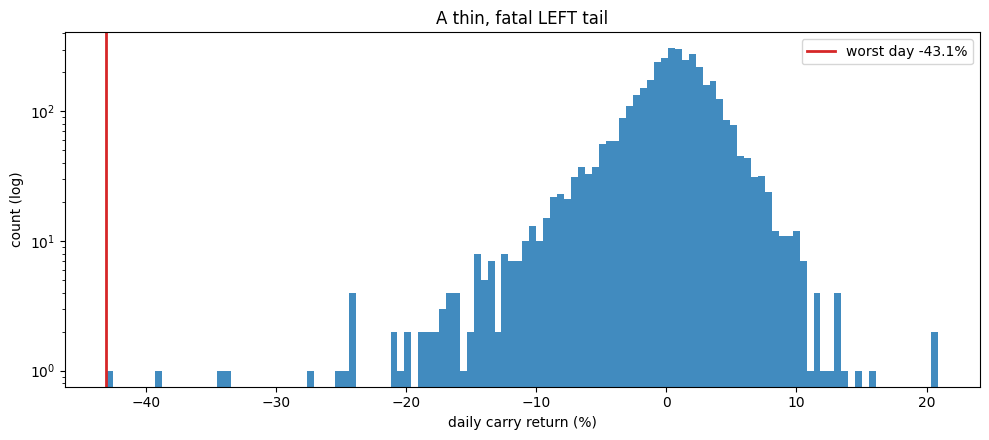

In [4]:
r = carry['net']
print(f"skew {strategy._skew(r.to_numpy()):+.2f}  excess kurtosis {strategy._excess_kurt(r.to_numpy()):+.1f}")
worst = r.nsmallest(5)
print('5 worst single days for the short-vol carry:')
for d, v in worst.items():
    print(f'  {d.date()}  {v*100:+.1f}%')
fig, ax = plt.subplots(figsize=(10,4.5))
ax.hist(r*100, bins=120, color='C0', alpha=.85)
ax.axvline(r.min()*100, color='C3', lw=2, label=f'worst day {r.min()*100:.1f}%')
ax.set_yscale('log'); ax.set_xlabel('daily carry return (%)'); ax.set_ylabel('count (log)')
ax.set_title('A thin, fatal LEFT tail'); ax.legend(); plt.tight_layout(); plt.show()

> 💡 **In plain words:** the five worst days are the 2018, 2020 and 2024 vol spikes. The payoff is the textbook shape of *short insurance* — many small premiums, rare ruinous claims.

**Survivable sizing** — solve the leverage so the worst historical day costs ≤25% of capital, then show de-levering does **not** lift the Sharpe (you only scale a single-asset short):

In [5]:
print(f"survivable leverage = {sized['leverage']:.3f}x  (worst up-day of VIXY = {sized['worst_up_move']*100:+.1f}%)")
sb = sized['backtest']
print(f"at that size: CAGR {sb['cagr']*100:+.2f}%/yr  Sharpe {sb['sharpe']:.3f}  maxDD {sb['max_dd']*100:.1f}%")
print(f"vs 1x:        CAGR {carry['cagr']*100:+.2f}%/yr  Sharpe {carry['sharpe']:.3f}  maxDD {carry['max_dd']*100:.1f}%")
print('=> Sharpe is identical (linear scaling); the tail just sets the scale, and the scale that survives is tiny.')

survivable leverage = 0.581x  (worst up-day of VIXY = +43.1%)
at that size: CAGR +15.67%/yr  Sharpe 0.568  maxDD -72.0%
vs 1x:        CAGR +14.79%/yr  Sharpe 0.568  maxDD -92.3%
=> Sharpe is identical (linear scaling); the tail just sets the scale, and the scale that survives is tiny.


> 💡 **In plain words:** you can't diversify away a one-day −43% move in the only thing you hold. You can only hold less of it — which shrinks the carry in lock-step. There is no size at which this is easy money.

## 5 · The verdict

Signal `REAL` (carry +14.79%/yr, Sharpe 0.57, HAC *t* +2.31), Tradability `FRAGILE` (skew -1.66, kurtosis +9.4, maxDD -92.3%; survivable only at 0.581× where the drawdown is still -72.0%), Free money? `BUSTED` (a compensated variance risk premium — you are short the crash).

## 6 · Could you trade it?

Capacity is fine (VIXY/SVXY are liquid). The binding constraint is the tail: survivable size is ~**0.581×** of capital, the carry at that size is modest, and the drawdown is still **-72.0%**. The economic content is a *short variance-risk-premium* position — real, compensated, and lethal when mis-sized (XIV, 2018). Fragile, not investable as "free money."

## 7 · Going further

- Condition the short on the **VIX futures term-structure slope** (front/second-month roll) — does timing the contango dodge spikes, or sell the cheapest insurance into the storm?
- **Tail-hedge** the short with a small static long-vol position; recompute the carry's skew and maxDD net of the hedge cost.
- Bootstrap a CI on the Sharpe and a **block-bootstrap** of the worst-drawdown distribution to size against the spike you *haven't seen yet*, not just the worst in-sample one.